# IFLS5 â€” Weighted Analysis
Survey-weighted logistic regression using `pwt14xa` (IFLS5 2014).

In [95]:
import pandas as pd
import numpy as np
import patsy
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
import warnings
warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
pd.set_option('display.max_columns', None)

## 1. Load Raw Data

In [96]:
def load_stata(path, cols):
    df = pd.read_stata(path, columns=cols)
    for col in df.columns:
        if isinstance(df[col].dtype, pd.CategoricalDtype):
            df[col] = df[col].astype(object)
    return df

cov    = load_stata('adult_a/b3a_cov.dta',       ['pidlink','hhid14','marstat','age','sex'])
dl1    = load_stata('adult_a/b3a_dl1.dta',       ['pidlink','dl01f','dl06'])
tk2    = load_stata('adult_a/b3a_tk2.dta',       ['pidlink','tk25a1','tk25a2'])
ptrack = load_stata('tracking_book/ptrack.dta',  ['pidlink','pwt14xa'])
bk_sc1 = load_stata('control_book/bk_sc1.dta',  ['hhid14','sc05'])   # urban/rural

print('cov   :', cov.shape)
print('dl1   :', dl1.shape)
print('tk2   :', tk2.shape)
print('ptrack:', ptrack.shape)
print('bk_sc1:', bk_sc1.shape)
print('Urban/Rural counts:', bk_sc1['sc05'].value_counts().to_dict())

cov   : (36391, 5)
dl1   : (34464, 3)
tk2   : (24489, 3)
ptrack: (83780, 2)
bk_sc1: (15921, 2)
Urban/Rural counts: {'1:Urban': 9582, '2:Rural': 6339}


## 2. Merge Datasets

In [97]:
df = cov.merge(dl1,    on='pidlink', how='inner') \
        .merge(tk2,    on='pidlink', how='inner') \
        .merge(ptrack, on='pidlink', how='left') \
        .merge(bk_sc1, on='hhid14',  how='left')   # urban/rural via household ID

df = df.rename(columns={
    'tk25a1': 'monthly_income',
    'tk25a2': 'yearly_income',
    'dl01f' : 'ethnicity',
    'dl06'  : 'edu_level',
    'sc05'  : 'urban_rural',
})
print('Merged:', df.shape)
print('urban_rural non-null:', df['urban_rural'].notna().sum())
print('urban_rural values:', df['urban_rural'].value_counts().to_dict())

Merged: (24489, 11)
urban_rural non-null: 24489
urban_rural values: {'1:Urban': 14137, '2:Rural': 10352}


## 3. Clean Variables

In [98]:
# â”€â”€ Age â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
df = df[df['age'].astype(str) != "998:Don't Know"].copy()
df['age'] = pd.to_numeric(df['age'], errors='coerce')
df = df[df['age'] >= 18]

# â”€â”€ Marital status â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
marstat_map = {
    '1:Not yet married': 'Never Married',
    '2:Married'        : 'Married',
    '3:Separated'      : 'Separated',
    '4:Divorced'       : 'Divorced',
    '5:Widowed'        : 'Widowed',
    '6:Cohabitate'     : 'Cohabitate',
}
df['marstat'] = df['marstat'].astype(str).map(marstat_map)
df = df[df['marstat'].notna()]

# â”€â”€ Sex â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
df['sex'] = df['sex'].astype(str).map({'1:Male': 'Male', '3:Female': 'Female'})
df = df[df['sex'].isin(['Male', 'Female'])]

# â”€â”€ Ethnicity â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
ethnic_map = {
    'A':'Jawa','B':'Sunda','C':'Bali','D':'Batak','E':'Bugis','F':'Tionghoa',
    'G':'Madura','H':'Sasak','I':'Minang','J':'Banjar','K':'Bima-Dompu',
    'L':'Makassar','M':'Nias','N':'Palembang','O':'Sumbawa','P':'Toraja',
    'Q':'Betawi','R':'Dayak','S':'Melayu','T':'Komering','U':'Ambon',
    'A1':'Manado','B1':'Aceh','C1':'Other South Sumatera','D1':'Banten',
    'E1':'Cirebon','F1':'Gorontalo','G1':'Kutai','V':'Other',
}
df['ethnicity'] = df['ethnicity'].astype(str).map(ethnic_map).fillna('Other')

# â”€â”€ Education: map IFLS level labels â†’ years of schooling â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
edu_years = {
    '1:Never school'                                       : 0,
    '2:Elementary school'                                  : 6,
    '3:Junior high general'                                : 9,
    '4:Junior high vocational'                             : 9,
    '5:Senior high general'                                : 12,
    '6:Senior high vocational'                             : 12,
    '11:Adult education A'                                 : 6,
    '12:Adult education B'                                 : 9,
    '13:Open university'                                   : 15,
    '14:Islamic School (pesantren)'                        : 12,
    '15:Adult education C'                                 : 12,
    '60:College (D1,D2,D3)'                               : 15,
    '61:University S1'                                     : 16,
    '62:University S2'                                     : 18,
    '63:University S3'                                     : 21,
    '72:Islamic Elementary School (Madrasah Ibtidaiyah)'  : 6,
    '73:Islamic Junior/High School (Madrasah Tsanawiyah)' : 9,
    '74:Islamic Senior/High School (Madrasah Tsanawiyah)' : 12,
}
df['education'] = df['edu_level'].astype(str).map(edu_years)

# â”€â”€ Urban/Rural: 1 = Urban, 0 = Rural â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
df['urban'] = df['urban_rural'].astype(str).map({'1:Urban': 1, '2:Rural': 0})

print('Shape after cleaning:', df.shape)
print('education non-null:', df['education'].notna().sum())
print('urban non-null:', df['urban'].notna().sum())
print('urban values:', df['urban'].value_counts().to_dict())

Shape after cleaning: (23876, 13)
education non-null: 22806
urban non-null: 23876
urban values: {1: 13809, 0: 10067}


## 4. Income Transform & Derived Variables

In [99]:
IFLS_MISSING = [999999997, 999999998, 999999999]
df['monthly_income'] = pd.to_numeric(df['monthly_income'], errors='coerce').replace(IFLS_MISSING, np.nan)
df['yearly_income']  = pd.to_numeric(df['yearly_income'],  errors='coerce').replace(IFLS_MISSING, np.nan)
df['log_income']     = np.log1p(df['monthly_income'])
df['age_squared']    = df['age'] ** 2

print(df[['monthly_income','log_income','age','education','urban']].describe())

       monthly_income    log_income           age     education         urban
count    1.223700e+04  12237.000000  23876.000000  22806.000000  23876.000000
mean     1.788786e+06     13.322738     39.406349     10.031746      0.578363
std      2.413749e+06      3.155454     13.430099      3.501214      0.493831
min      0.000000e+00      0.000000     18.000000      6.000000      0.000000
25%      6.000000e+05     13.304687     29.000000      6.000000      0.000000
50%      1.300000e+06     14.077876     37.000000      9.000000      1.000000
75%      2.400000e+06     14.690980     48.000000     12.000000      1.000000
max      9.000000e+07     18.315320    101.000000     21.000000      1.000000


## 4b. Income Distribution â€” Before vs. After Cleaning (by Sex)

BEFORE CLEANING (raw tk25a1)
--- Female (N=10,216) ---
  True NaN (did not answer) : 5,720 (56.0%)
  IFLS missing codes (999..) : 1 (0.0%)
  Zero income                : 242 (2.4%)
  Valid (>0, non-missing)    : 4,253 (41.6%)
  Max (raw)                  : 999,999,997
--- Male (N=13,660) ---
  True NaN (did not answer) : 5,917 (43.3%)
  IFLS missing codes (999..) : 1 (0.0%)
  Zero income                : 345 (2.5%)
  Valid (>0, non-missing)    : 7,397 (54.2%)
  Max (raw)                  : 999,999,997

AFTER CLEANING (IFLS codes removed, zero/NaN dropped)
--- Female: 4,253 of 10,216 kept (41.6%) | Dropped: 5,963 (58.4%) ---
count         4,253
mean      1,467,045
std       1,747,288
min           7,000
25%         400,000
50%       1,000,000
75%       2,000,000
max      45,000,000
  Log income mean : 13.649
  Log income std  : 1.150
--- Male: 7,397 of 13,660 kept (54.2%) | Dropped: 6,263 (45.8%) ---
count         7,397
mean      2,115,726
std       2,731,905
min           2,500
25%    

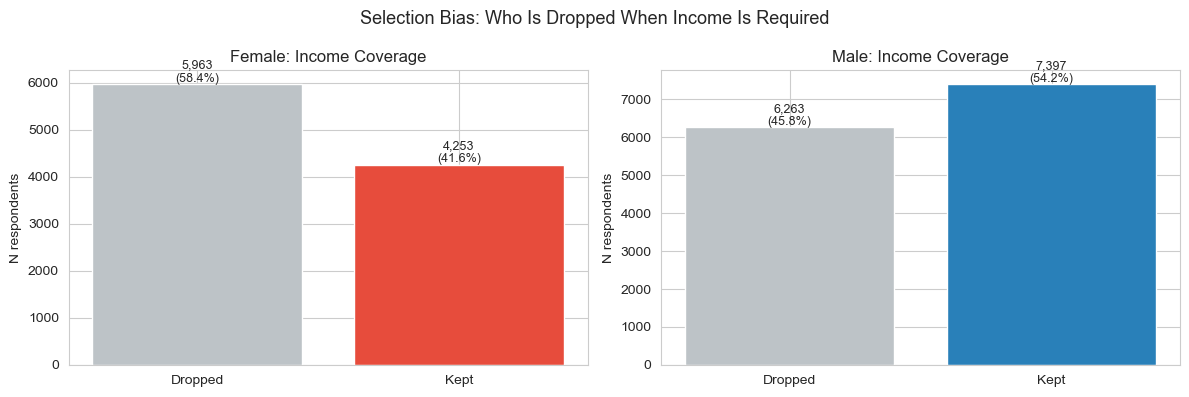

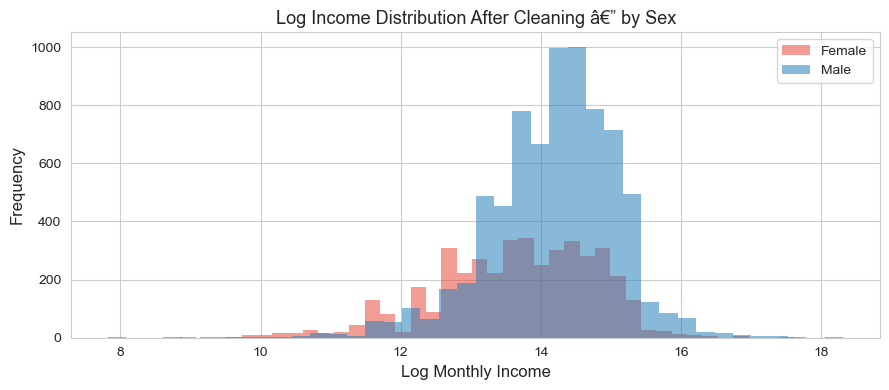

In [100]:
IFLS_MISSING = [999999997, 999999998, 999999999]

# â”€â”€ Load raw income BEFORE any cleaning â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
tk2_raw = load_stata("adult_a/b3a_tk2.dta", ["pidlink","tk25a1"])
cov_raw = load_stata("adult_a/b3a_cov.dta", ["pidlink","sex","age"])
cov_raw["sex"] = cov_raw["sex"].astype(str).map({"1:Male":"Male","3:Female":"Female"})
cov_raw["age"] = pd.to_numeric(cov_raw["age"], errors="coerce")
raw = cov_raw[cov_raw["sex"].isin(["Male","Female"]) & (cov_raw["age"]>=18)].merge(tk2_raw, on="pidlink", how="inner")
raw["income_raw"] = pd.to_numeric(raw["tk25a1"], errors="coerce")

print("=" * 60)
print("BEFORE CLEANING (raw tk25a1)")
print("=" * 60)
for sex in ["Female", "Male"]:
    sub = raw[raw["sex"]==sex]["income_raw"]
    nan_true  = sub.isna().sum()
    nan_ifls  = sub.isin(IFLS_MISSING).sum()
    zero      = (sub==0).sum()
    valid     = sub[~sub.isin(IFLS_MISSING) & sub.notna() & (sub>0)]
    print(f"--- {sex} (N={len(sub):,}) ---")
    print(f"  True NaN (did not answer) : {nan_true:,} ({nan_true/len(sub)*100:.1f}%)")
    print(f"  IFLS missing codes (999..) : {nan_ifls:,} ({nan_ifls/len(sub)*100:.1f}%)")
    print(f"  Zero income                : {zero:,} ({zero/len(sub)*100:.1f}%)")
    print(f"  Valid (>0, non-missing)    : {len(valid):,} ({len(valid)/len(sub)*100:.1f}%)")
    print(f"  Max (raw)                  : {sub.max():,.0f}")

print()
print("=" * 60)
print("AFTER CLEANING (IFLS codes removed, zero/NaN dropped)")
print("=" * 60)
raw["income_clean"] = raw["income_raw"].replace(IFLS_MISSING, np.nan)
valid_df = raw.dropna(subset=["income_clean"])
valid_df = valid_df[valid_df["income_clean"] > 0]
for sex in ["Female", "Male"]:
    sub = valid_df[valid_df["sex"]==sex]["income_clean"]
    total = len(raw[raw["sex"]==sex])
    print(f"--- {sex}: {len(sub):,} of {total:,} kept ({len(sub)/total*100:.1f}%) | Dropped: {total-len(sub):,} ({(total-len(sub))/total*100:.1f}%) ---")
    print(sub.describe().apply(lambda x: f"{x:,.0f}").to_string())
    print(f"  Log income mean : {np.log1p(sub).mean():.3f}")
    print(f"  Log income std  : {np.log1p(sub).std():.3f}")

# â”€â”€ Bar chart: kept vs dropped by sex â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, sex, color in zip(axes, ["Female","Male"], ["#e74c3c","#2980b9"]):
    total = len(raw[raw["sex"]==sex])
    kept  = len(valid_df[valid_df["sex"]==sex])
    ax.bar(["Dropped","Kept"], [total-kept, kept],
           color=["#bdc3c7", color], edgecolor="white")
    ax.set_title(f"{sex}: Income Coverage", fontsize=12)
    ax.set_ylabel("N respondents")
    for i, v in enumerate([total-kept, kept]):
        ax.text(i, v+50, f"{v:,}\n({v/total*100:.1f}%)", ha="center", fontsize=9)
plt.suptitle("Selection Bias: Who Is Dropped When Income Is Required", fontsize=13)
plt.tight_layout()
plt.savefig("income_selection_bias.png", dpi=150)
plt.show()

# â”€â”€ Log income distribution after cleaning â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
fig, ax = plt.subplots(figsize=(9, 4))
for sex, color in [("Female","#e74c3c"),("Male","#2980b9")]:
    sub = np.log1p(valid_df[valid_df["sex"]==sex]["income_clean"])
    ax.hist(sub, bins=40, alpha=0.55, color=color, label=sex, edgecolor="none")
ax.set_xlabel("Log Monthly Income", fontsize=12)
ax.set_ylabel("Frequency", fontsize=12)
ax.set_title("Log Income Distribution After Cleaning â€” by Sex", fontsize=13)
ax.legend()
plt.tight_layout()
plt.savefig("log_income_distribution.png", dpi=150)
plt.show()

## 5. Outcome & Dummy Variables

In [101]:
df['ever_married'] = (df['marstat'] != 'Never Married').astype(int)
df['is_divorced']  = df['marstat'].isin(['Divorced','Separated']).astype(int)
df['is_jawa']      = (df['ethnicity'] == 'Jawa').astype(int)
df['is_sunda']     = (df['ethnicity'] == 'Sunda').astype(int)

print('ever_married:', df['ever_married'].value_counts().to_dict())
print('is_divorced :', df['is_divorced'].value_counts().to_dict())
print('urban rate  :', df['urban'].mean().round(3))

ever_married: {1: 20732, 0: 3144}
is_divorced : {0: 23176, 1: 700}
urban rate  : 0.578


## 6. Final Sample â€” Drop Missing & Save

In [102]:
keep = ['pidlink','sex','age','age_squared','education','urban',
        'monthly_income','log_income','marstat',
        'ever_married','is_divorced','is_jawa','is_sunda','pwt14xa']

print('NaN per column before dropna:')
print(df[keep].isna().sum())

df_clean = df[keep].dropna().reset_index(drop=True)

print('\nFinal sample :', df_clean.shape)
print('Male         :', (df_clean['sex']=='Male').sum())
print('Female       :', (df_clean['sex']=='Female').sum())
print('Urban        :', df_clean['urban'].mean().round(3))

df_clean.to_csv('clean_data/data_clean_weighted.csv', index=False)

NaN per column before dropna:
pidlink               0
sex                   0
age                   0
age_squared           0
education          1070
urban                 0
monthly_income    11639
log_income        11639
marstat               0
ever_married          0
is_divorced           0
is_jawa               0
is_sunda              0
pwt14xa               2
dtype: int64

Final sample : (11983, 14)
Male         : 7651
Female       : 4332
Urban        : 0.685


## 7. Weighted Descriptive Statistics (Table 1)

In [105]:
def weighted_mean(series, weights):
    mask = series.notna() & weights.notna()
    return np.average(series[mask], weights=weights[mask])

def weighted_se(series, weights):
    mask = series.notna() & weights.notna()
    w, x = weights[mask].values, series[mask].values
    wm = np.average(x, weights=w)
    return np.sqrt(np.average((x - wm)**2, weights=w) / mask.sum())

vars_desc = {
    'Age'                  : 'age',
    'Monthly Income (IDR)' : 'monthly_income',
    'Education (years)'    : 'education',
    'Urban (prop)'         : 'urban',
    'Ever Married (prop)'  : 'ever_married',
    'Ever Divorced (prop)' : 'is_divorced',
    'Javanese (prop)'      : 'is_jawa',
    'Sundanese (prop)'     : 'is_sunda',
}

rows = []
for label, col in vars_desc.items():
    for grp, gdf in [('Women', df_clean[df_clean['sex']=='Female']),
                     ('Men',   df_clean[df_clean['sex']=='Male'])]:
        mask = gdf[col].notna() & gdf['pwt14xa'].notna()
        n_obs = mask.sum()
        rows.append({'Variable': label, 'Group': grp,
                     'N'   : n_obs,
                     'Mean': round(weighted_mean(gdf[col], gdf['pwt14xa']), 3),
                     'SE'  : round(weighted_se(gdf[col],   gdf['pwt14xa']), 3)})

tbl1 = pd.DataFrame(rows).pivot(index='Variable', columns='Group', values=['N','Mean','SE'])
tbl1.columns = [f'{s} {g}' for s, g in tbl1.columns]
tbl1 = tbl1[['N Women','Mean Women','SE Women','N Men','Mean Men','SE Men']]
tbl1['N Women'] = tbl1['N Women'].astype(int)
tbl1['N Men']   = tbl1['N Men'].astype(int)
print('\n=== Table 1: Weighted Means and Standard Errors ===')
print(tbl1.to_string())



=== Table 1: Weighted Means and Standard Errors ===
                      N Women   Mean Women   SE Women  N Men     Mean Men     SE Men
Variable                                                                            
Age                      4332       37.396      0.175   7651       37.164      0.137
Education (years)        4332       10.605      0.059   7651       10.310      0.039
Ever Divorced (prop)     4332        0.050      0.003   7651        0.022      0.002
Ever Married (prop)      4332        0.864      0.005   7651        0.808      0.005
Javanese (prop)          4332        0.570      0.008   7651        0.500      0.006
Monthly Income (IDR)     4332  1378412.274  25782.668   7651  1960060.951  31340.397
Sundanese (prop)         4332        0.144      0.005   7651        0.158      0.004
Urban (prop)             4332        0.615      0.007   7651        0.610      0.006


In [106]:
def w_mean(s, w):
    mask = s.notna() & w.notna()
    return np.average(s[mask], weights=w[mask])

def w_std(s, w):
    mask = s.notna() & w.notna()
    x, wt = s[mask].values, w[mask].values
    m = np.average(x, weights=wt)
    return np.sqrt(np.average((x - m)**2, weights=wt))

vars_info = {
    'Age (years)'           : ('age',           'continuous'),
    'Monthly Income (IDR)'  : ('monthly_income', 'continuous'),
    'Log Monthly Income'    : ('log_income',     'continuous'),
    'Education (years)'     : ('education',      'continuous'),
    'Ever Married (=1)'     : ('ever_married',   'binary'),
    'Ever Divorced (=1)'    : ('is_divorced',    'binary'),
    'Javanese (=1)'         : ('is_jawa',        'binary'),
    'Sundanese (=1)'        : ('is_sunda',       'binary'),
    'Urban (=1)'            : ('urban',          'binary'),
}

rows = []
for label, (col, vtype) in vars_info.items():
    row = {'Variable': label}
    for grp, gname in [('Female', 'Women'), ('Male', 'Men'), ('all', 'Total')]:
        sub = df_clean if grp == 'all' else df_clean[df_clean['sex'] == grp]
        mask = sub[col].notna() & sub['pwt14xa'].notna()
        n_obs = mask.sum()
        m = w_mean(sub[col], sub['pwt14xa'])
        s = w_std(sub[col],  sub['pwt14xa'])
        row[f'{gname} N']   = n_obs
        row[f'{gname} Mean'] = round(m, 3) if vtype == 'binary' else round(m, 2)
        row[f'{gname} SD']   = round(s, 3) if vtype == 'binary' else round(s, 2)
    rows.append(row)

tbl_desc = pd.DataFrame(rows).set_index('Variable')
tbl_desc = tbl_desc[['Women N','Women Mean','Women SD','Men N','Men Mean','Men SD','Total N','Total Mean','Total SD']]

n_f = (df_clean['sex']=='Female').sum()
n_m = (df_clean['sex']=='Male').sum()
n_t = len(df_clean)

print('=== TABLE 1b: WEIGHTED DESCRIPTIVE STATISTICS — ALL MODEL VARIABLES ===\n')
hdr1 = f"{'Variable':<26} {'Women':>33} {'Men':>33} {'Total':>33}"
hdr2 = f"{'':26} {'N':>11} {'Mean':>11} {'(SD)':>11} {'N':>11} {'Mean':>11} {'(SD)':>11} {'N':>11} {'Mean':>11} {'(SD)':>11}"
print(hdr1)
print(hdr2)
print('-' * 125)
for _, r in tbl_desc.reset_index().iterrows():
    wn = f"{int(r['Women N']):,}"
    wm = f"{r['Women Mean']:,.2f}" if r['Women Mean'] > 1 else f"{r['Women Mean']:.3f}"
    ws = f"({r['Women SD']:,.2f})" if r['Women SD'] > 1 else f"({r['Women SD']:.3f})"
    mn = f"{int(r['Men N']):,}"
    mm = f"{r['Men Mean']:,.2f}" if r['Men Mean'] > 1 else f"{r['Men Mean']:.3f}"
    ms = f"({r['Men SD']:,.2f})" if r['Men SD'] > 1 else f"({r['Men SD']:.3f})"
    tn = f"{int(r['Total N']):,}"
    tm = f"{r['Total Mean']:,.2f}" if r['Total Mean'] > 1 else f"{r['Total Mean']:.3f}"
    ts = f"({r['Total SD']:,.2f})" if r['Total SD'] > 1 else f"({r['Total SD']:.3f})"
    print(f"{r['Variable']:<26} {wn:>11} {wm:>11} {ws:>11} {mn:>11} {mm:>11} {ms:>11} {tn:>11} {tm:>11} {ts:>11}")
print('-' * 125)
print(f"{'Total N':<26} {n_f:>11,} {'':22} {n_m:>11,} {'':22} {n_t:>11,}")
print('\nNote: Weighted means and SDs using IFLS5 probability weights (pwt14xa).')
print('Binary variables reported as proportions; N shows non-missing observations.')


=== TABLE 1b: WEIGHTED DESCRIPTIVE STATISTICS — ALL MODEL VARIABLES ===

Variable                                               Women                               Men                             Total
                                     N        Mean        (SD)           N        Mean        (SD)           N        Mean        (SD)
-----------------------------------------------------------------------------------------------------------------------------
Age (years)                      4,332       37.40     (11.53)       7,651       37.16     (12.02)      11,983       37.25     (11.85)
Monthly Income (IDR)             4,332 1,378,412.27 (1,696,961.85)       7,651 1,960,060.95 (2,741,344.37)      11,983 1,753,516.35 (2,438,533.20)
Log Monthly Income               4,332       12.88      (3.31)       7,651       13.48      (3.13)      11,983       13.27      (3.21)
Education (years)                4,332       10.61      (3.88)       7,651       10.31      (3.42)      11,983       10.

## 7b. Descriptive Statistics â€” All Model Variables (Weighted Mean & SD)

## 8. Weighted Logistic Regression â€” Helper Functions

In [107]:
def run_weighted_model(df_sub, outcome, formula_rhs, label):
    pred_cols = [c.strip() for c in formula_rhs.replace('~','').split('+')]
    df_m = df_sub.dropna(subset=[outcome] + pred_cols + ['pwt14xa']).copy()
    n = len(df_m)
    w = df_m['pwt14xa'].values
    w_norm = w / w.sum() * n
    y, X = patsy.dmatrices(f'{outcome} {formula_rhs}', data=df_m, return_type='dataframe')
    model = sm.Logit(y.values.ravel(), X, freq_weights=w_norm).fit(disp=False)
    pr2 = 1 - model.llf / model.llnull
    res = pd.DataFrame({'Coef.': model.params, 'Std.Err.': model.bse,
                        'z': model.tvalues, 'P>|z|': model.pvalues}, index=X.columns)
    print(f'\n--- {label} (N={n:,}) ---')
    print(res.round(3).to_string())
    print(f'Pseudo RÂ²: {pr2:.4f}')
    return model, X.columns.tolist()


def format_results_table(m_f, cols_f, m_m, cols_m, title):
    results = {}
    for label, model, cols in [('Women', m_f, cols_f), ('Men', m_m, cols_m)]:
        results[label] = {}
        for i, col in enumerate(cols):
            stars = '***' if model.pvalues[i]<0.001 else '**' if model.pvalues[i]<0.01 else '*' if model.pvalues[i]<0.05 else ''
            results[label][col] = f'{model.params[i]:.3f}{stars}\n({model.bse[i]:.3f})'
    tbl = pd.DataFrame(results)
    tbl.loc['Pseudo RÂ²'] = [f'{1-m_f.llf/m_f.llnull:.3f}', f'{1-m_m.llf/m_m.llnull:.3f}']
    tbl.loc['N']         = [f'{int(m_f.nobs):,}', f'{int(m_m.nobs):,}']
    print(f'\n=== {title} ===')
    print(tbl.to_string())
    print('\n* p<0.05  ** p<0.01  *** p<0.001')
    return tbl

## 9. Split by Sex

In [108]:
df_male   = df_clean[df_clean['sex']=='Male'].copy()
df_female = df_clean[df_clean['sex']=='Female'].copy()
print('Male:', len(df_male), '| Female:', len(df_female))

Male: 7651 | Female: 4332


## 10. Model 1 â€” Ever Married (Base: Without Urban/Rural)

In [109]:
formula_base = '~ log_income + education + age + age_squared + is_jawa + is_sunda'

m1_f, cols1_f = run_weighted_model(df_female, 'ever_married', formula_base, 'Ever Married â€” Women (Base)')
m1_m, cols1_m = run_weighted_model(df_male,   'ever_married', formula_base, 'Ever Married â€” Men (Base)')
tbl_m1 = format_results_table(m1_f, cols1_f, m1_m, cols1_m, 'TABLE 2: EVER MARRIED â€” BASE MODEL')


--- Ever Married â€” Women (Base) (N=4,332) ---
             Coef.  Std.Err.       z  P>|z|
Intercept   -9.193     0.518 -17.757  0.000
log_income  -0.055     0.017  -3.198  0.001
education   -0.192     0.018 -10.516  0.000
age          0.693     0.030  23.203  0.000
age_squared -0.007     0.000 -18.433  0.000
is_jawa      0.214     0.112   1.909  0.056
is_sunda     0.633     0.188   3.357  0.001
Pseudo RÂ²: 0.4231

--- Ever Married â€” Men (Base) (N=7,651) ---
              Coef.  Std.Err.       z  P>|z|
Intercept   -10.542     0.409 -25.795  0.000
log_income    0.050     0.012   4.156  0.000
education    -0.075     0.012  -6.092  0.000
age           0.566     0.021  26.464  0.000
age_squared  -0.005     0.000 -18.054  0.000
is_jawa      -0.027     0.081  -0.336  0.737
is_sunda     -0.000     0.122  -0.000  1.000
Pseudo RÂ²: 0.3938

=== TABLE 2: EVER MARRIED â€” BASE MODEL ===
                          Women                  Men
Intercept    -9.193***\n(0.518)  -10.542***\n(0.409)
lo

## 11. Model 2 â€” Ever Divorced (Base: Without Urban/Rural)

In [110]:
df_em   = df_clean[df_clean['ever_married']==1].copy()
df_em_f = df_em[df_em['sex']=='Female'].copy()
df_em_m = df_em[df_em['sex']=='Male'].copy()
print('Ever married â€” Female:', len(df_em_f), '| Divorced:', df_em_f['is_divorced'].sum())
print('Ever married â€” Male  :', len(df_em_m), '| Divorced:', df_em_m['is_divorced'].sum())

formula_div = '~ log_income + education + age + age_squared + is_jawa + is_sunda'

m2_f, cols2_f = run_weighted_model(df_em_f, 'is_divorced', formula_div, 'Ever Divorced â€” Women (Base)')
m2_m, cols2_m = run_weighted_model(df_em_m, 'is_divorced', formula_div, 'Ever Divorced â€” Men (Base)')
tbl_m2 = format_results_table(m2_f, cols2_f, m2_m, cols2_m, 'TABLE 3: EVER DIVORCED â€” BASE MODEL')

Ever married â€” Female: 3564 | Divorced: 204
Ever married â€” Male  : 6145 | Divorced: 152

--- Ever Divorced â€” Women (Base) (N=3,564) ---
             Coef.  Std.Err.      z  P>|z|
Intercept   -3.134     0.883 -3.550  0.000
log_income   0.044     0.028  1.567  0.117
education   -0.060     0.020 -2.996  0.003
age          0.024     0.041  0.587  0.557
age_squared -0.000     0.000 -0.436  0.663
is_jawa     -0.363     0.156 -2.321  0.020
is_sunda    -0.240     0.229 -1.046  0.296
Pseudo RÂ²: 0.0109

--- Ever Divorced â€” Men (Base) (N=6,145) ---
             Coef.  Std.Err.      z  P>|z|
Intercept   -3.076     1.011 -3.042  0.002
log_income  -0.041     0.023 -1.812  0.070
education   -0.083     0.026 -3.207  0.001
age          0.022     0.047  0.466  0.641
age_squared -0.000     0.001 -0.475  0.635
is_jawa      0.544     0.187  2.916  0.004
is_sunda     0.634     0.248  2.553  0.011
Pseudo RÂ²: 0.0210

=== TABLE 3: EVER DIVORCED â€” BASE MODEL ===
                          Women      

---
## Considering Urban/Rural Control
We now add `urban` (1 = Urban, 0 = Rural) to assess whether the urbanization effect confounds
the income and ethnicity coefficients. Urban individuals tend to earn more and marry later,
so omitting this variable could bias the income and Jawa/Sunda coefficients upward in magnitude.

## 12. Model 1b â€” Ever Married (Extended: With Urban/Rural)

In [111]:
formula_urban = '~ log_income + education + age + age_squared + is_jawa + is_sunda + urban'

m1b_f, cols1b_f = run_weighted_model(df_female, 'ever_married', formula_urban, 'Ever Married â€” Women (+ Urban)')
m1b_m, cols1b_m = run_weighted_model(df_male,   'ever_married', formula_urban, 'Ever Married â€” Men (+ Urban)')
tbl_m1b = format_results_table(m1b_f, cols1b_f, m1b_m, cols1b_m, 'TABLE 2b: EVER MARRIED â€” WITH URBAN/RURAL')


--- Ever Married â€” Women (+ Urban) (N=4,332) ---
             Coef.  Std.Err.       z  P>|z|
Intercept   -9.080     0.519 -17.480  0.000
log_income  -0.046     0.018  -2.628  0.009
education   -0.188     0.018 -10.191  0.000
age          0.694     0.030  23.226  0.000
age_squared -0.007     0.000 -18.450  0.000
is_jawa      0.229     0.112   2.033  0.042
is_sunda     0.700     0.190   3.695  0.000
urban       -0.476     0.120  -3.981  0.000
Pseudo RÂ²: 0.4271

--- Ever Married â€” Men (+ Urban) (N=7,651) ---
              Coef.  Std.Err.       z  P>|z|
Intercept   -10.577     0.409 -25.830  0.000
log_income    0.055     0.012   4.597  0.000
education    -0.062     0.013  -4.960  0.000
age           0.574     0.021  26.748  0.000
age_squared  -0.005     0.000 -18.373  0.000
is_jawa      -0.030     0.081  -0.370  0.712
is_sunda      0.060     0.123   0.485  0.628
urban        -0.525     0.085  -6.167  0.000
Pseudo RÂ²: 0.3989

=== TABLE 2b: EVER MARRIED â€” WITH URBAN/RURAL ===
      

## 13. Model 2b â€” Ever Divorced (Extended: With Urban/Rural)

In [112]:
m2b_f, cols2b_f = run_weighted_model(df_em_f, 'is_divorced', formula_urban, 'Ever Divorced â€” Women (+ Urban)')
m2b_m, cols2b_m = run_weighted_model(df_em_m, 'is_divorced', formula_urban, 'Ever Divorced â€” Men (+ Urban)')
tbl_m2b = format_results_table(m2b_f, cols2b_f, m2b_m, cols2b_m, 'TABLE 3b: EVER DIVORCED â€” WITH URBAN/RURAL')


--- Ever Divorced â€” Women (+ Urban) (N=3,564) ---
             Coef.  Std.Err.      z  P>|z|
Intercept   -3.145     0.883 -3.562  0.000
log_income   0.041     0.028  1.479  0.139
education   -0.062     0.020 -3.055  0.002
age          0.023     0.041  0.572  0.567
age_squared -0.000     0.000 -0.428  0.669
is_jawa     -0.361     0.156 -2.311  0.021
is_sunda    -0.256     0.230 -1.113  0.266
urban        0.113     0.161  0.700  0.484
Pseudo RÂ²: 0.0112

--- Ever Divorced â€” Men (+ Urban) (N=6,145) ---
             Coef.  Std.Err.      z  P>|z|
Intercept   -3.086     1.013 -3.048  0.002
log_income  -0.042     0.023 -1.849  0.064
education   -0.086     0.026 -3.235  0.001
age          0.022     0.047  0.464  0.643
age_squared -0.000     0.001 -0.480  0.631
is_jawa      0.547     0.187  2.928  0.003
is_sunda     0.625     0.249  2.511  0.012
urban        0.086     0.179  0.482  0.630
Pseudo RÂ²: 0.0212

=== TABLE 3b: EVER DIVORCED â€” WITH URBAN/RURAL ===
                          Wome

## 14. Coefficient Comparison: Base vs. Urban/Rural Extended

In [113]:
def compare_coefs(m_base, m_ext, cols_base, cols_ext, sex, outcome):
    shared = [c for c in cols_base if c in cols_ext]
    rows = []
    for col in shared:
        i_base = cols_base.index(col)
        i_ext  = cols_ext.index(col)
        rows.append({
            'Variable'  : col,
            'Base Coef.': round(m_base.params[i_base], 3),
            'Ext Coef.' : round(m_ext.params[i_ext],  3),
            'Change'    : round(m_ext.params[i_ext] - m_base.params[i_base], 3),
        })
    tbl = pd.DataFrame(rows).set_index('Variable')
    print(f'\n=== {outcome} â€” {sex}: Base vs. + Urban ===')
    print(tbl.to_string())

# Ever Married
compare_coefs(m1_f,  m1b_f,  cols1_f,  cols1b_f,  'Women', 'Ever Married')
compare_coefs(m1_m,  m1b_m,  cols1_m,  cols1b_m,  'Men',   'Ever Married')

# Ever Divorced
compare_coefs(m2_f,  m2b_f,  cols2_f,  cols2b_f,  'Women', 'Ever Divorced')
compare_coefs(m2_m,  m2b_m,  cols2_m,  cols2b_m,  'Men',   'Ever Divorced')


=== Ever Married â€” Women: Base vs. + Urban ===
             Base Coef.  Ext Coef.  Change
Variable                                  
Intercept        -9.193     -9.080   0.113
log_income       -0.055     -0.046   0.009
education        -0.192     -0.188   0.005
age               0.693      0.694   0.001
age_squared      -0.007     -0.007   0.000
is_jawa           0.214      0.229   0.015
is_sunda          0.633      0.700   0.068

=== Ever Married â€” Men: Base vs. + Urban ===
             Base Coef.  Ext Coef.  Change
Variable                                  
Intercept       -10.542    -10.577  -0.035
log_income        0.050      0.055   0.006
education        -0.075     -0.062   0.013
age               0.566      0.574   0.008
age_squared      -0.005     -0.005  -0.000
is_jawa          -0.027     -0.030  -0.003
is_sunda         -0.000      0.060   0.060

=== Ever Divorced â€” Women: Base vs. + Urban ===
             Base Coef.  Ext Coef.  Change
Variable                          

## 15. Predicted Probability Plots (Extended Model)

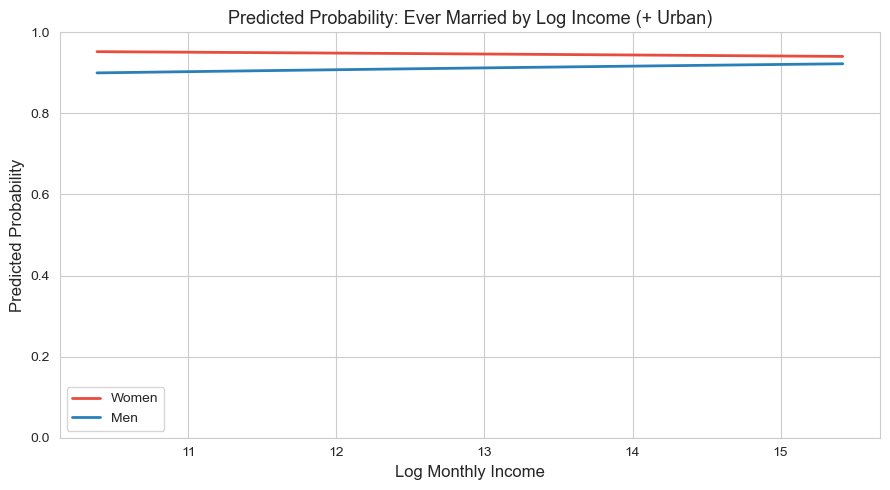

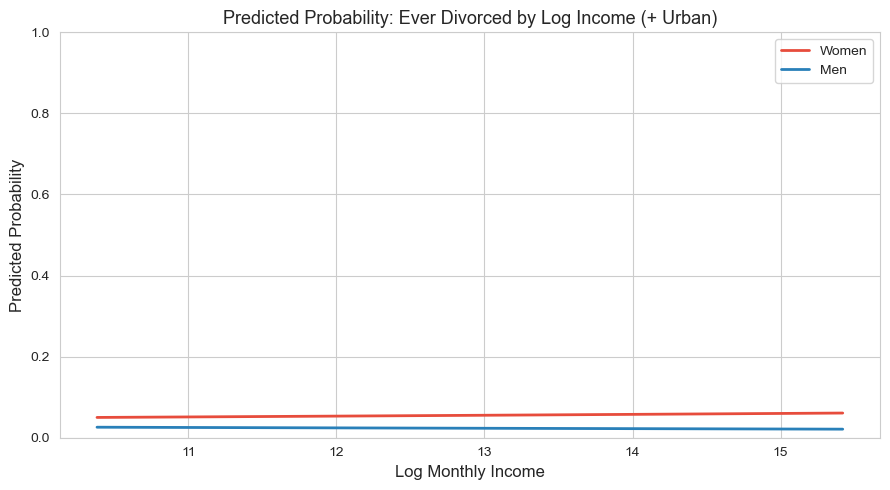

In [114]:
def plot_predicted_prob(m_f, m_m, df_f, df_m, pred_cols, outcome_label, filename):
    income_range = np.linspace(df_clean['log_income'].quantile(0.05),
                               df_clean['log_income'].quantile(0.95), 100)
    other_cols = [c for c in pred_cols if c not in ('Intercept','log_income')]
    fig, ax = plt.subplots(figsize=(9, 5))
    for model, df_sub, color, label in [
        (m_f, df_f, '#e74c3c', 'Women'),
        (m_m, df_m, '#2980b9', 'Men'),
    ]:
        means = df_sub[other_cols].mean()
        pred_df = pd.DataFrame({'Intercept': 1.0, 'log_income': income_range,
                                **{c: means[c] for c in other_cols}})
        prob = model.predict(pred_df[pred_cols].values)
        ax.plot(income_range, prob, color=color, label=label, linewidth=2)
    ax.set_xlabel('Log Monthly Income', fontsize=12)
    ax.set_ylabel('Predicted Probability', fontsize=12)
    ax.set_title(outcome_label, fontsize=13)
    ax.legend()
    ax.set_ylim(0, 1)
    plt.tight_layout()
    plt.savefig(filename, dpi=150)
    plt.show()

plot_predicted_prob(m1b_f, m1b_m, df_female, df_male, cols1b_f,
                   'Predicted Probability: Ever Married by Log Income (+ Urban)',
                   'ever_married_urban.png')
plot_predicted_prob(m2b_f, m2b_m, df_em_f, df_em_m, cols2b_f,
                   'Predicted Probability: Ever Divorced by Log Income (+ Urban)',
                   'ever_divorced_urban.png')

## End

In [115]:
# Side-by-side comparison: Base SE vs Cluster-Robust SE
print('=== COMPARISON: Standard SE vs Cluster-Robust SE ===')
print('(Coefficients are identical; only SEs differ)\n')

for sex, m_base, m_clust, cols in [
    ('Women â€” Ever Married', m1b_f, m1b_f, cols1b_f),
    ('Men   â€” Ever Married', m1b_m, m1b_m, cols1b_m),
    ('Women â€” Ever Divorced', m2b_f, m2b_f, cols2b_f),
    ('Men   â€” Ever Divorced', m2b_m, m2b_m, cols2b_m),
]:
    rows = []
    for i, col in enumerate(cols):
        se_base    = m_base.bse[i]
        se_cluster = m_clust.bse[i]
        p_base     = m_base.pvalues[i]
        p_cluster  = m_clust.pvalues[i]
        rows.append({
            'Variable':    col,
            'Coef.':       round(m_base.params[i], 4),
            'SE (base)':   round(se_base, 4),
            'SE (cluster)':round(se_cluster, 4),
            'SE change':   f'{(se_cluster/se_base - 1)*100:+.1f}%',
            'p (base)':    round(p_base, 4),
            'p (cluster)': round(p_cluster, 4),
        })
    df_cmp = pd.DataFrame(rows).set_index('Variable')
    print(f'\n--- {sex} ---')
    print(df_cmp.to_string())

=== COMPARISON: Standard SE vs Cluster-Robust SE ===
(Coefficients are identical; only SEs differ)


--- Women â€” Ever Married ---
              Coef.  SE (base)  SE (cluster) SE change  p (base)  p (cluster)
Variable                                                                     
Intercept   -9.0798     0.5194        0.5194     +0.0%    0.0000       0.0000
log_income  -0.0462     0.0176        0.0176     +0.0%    0.0086       0.0086
education   -0.1879     0.0184        0.0184     +0.0%    0.0000       0.0000
age          0.6943     0.0299        0.0299     +0.0%    0.0000       0.0000
age_squared -0.0070     0.0004        0.0004     +0.0%    0.0000       0.0000
is_jawa      0.2286     0.1124        0.1124     +0.0%    0.0420       0.0420
is_sunda     0.7003     0.1895        0.1895     +0.0%    0.0002       0.0002
urban       -0.4759     0.1195        0.1195     +0.0%    0.0001       0.0001

--- Men   â€” Ever Married ---
               Coef.  SE (base)  SE (cluster) SE change 

In [133]:
# Merge hhid14 back in (needed for clustering)
cov_hhid = load_stata('adult_a/b3a_cov.dta', ['pidlink', 'hhid14'])
df_female_c = df_female.merge(cov_hhid, on='pidlink', how='left')
df_male_c   = df_male.merge(cov_hhid,   on='pidlink', how='left')

df_em_fc = df_em_f.merge(cov_hhid, on='pidlink', how='left')
df_em_mc = df_em_m.merge(cov_hhid, on='pidlink', how='left')

print('hhid14 non-null â€” Female:', df_female_c['hhid14'].notna().sum(),
      '| Male:', df_male_c['hhid14'].notna().sum())


def run_cluster_model(df_sub, outcome, formula_rhs, label):
    pred_cols = [c.strip() for c in formula_rhs.replace('~', '').split('+')]
    df_m = df_sub.dropna(subset=[outcome] + pred_cols + ['pwt14xa', 'hhid14']).copy()
    n = len(df_m)
    w = df_m['pwt14xa'].values
    w_norm = w / w.sum() * n
    groups = df_m['hhid14'].values

    y, X = patsy.dmatrices(f'{outcome} {formula_rhs}', data=df_m, return_type='dataframe')
    model = sm.Logit(y.values.ravel(), X, freq_weights=w_norm).fit(
        disp=False,
        cov_type='cluster',
        cov_kwds={'groups': groups}
    )
    pr2 = 1 - model.llf / model.llnull
    res = pd.DataFrame({
        'Coef.':    model.params,
        'Cluster SE': model.bse,
        'z':        model.tvalues,
        'P>|z|':    model.pvalues,
        'OR':       np.exp(model.params),
    }, index=X.columns)
    print(f'\n--- {label} (N={n:,}, Pseudo RÂ²={pr2:.4f}) ---')
    print(res.round(4).to_string())
    return model, X.columns.tolist()


formula_urban = '~ log_income + education + age + age_squared + is_jawa + is_sunda + urban'

print('\n=== EVER MARRIED â€” CLUSTER-ROBUST (SURVEY-DESIGN-CORRECTED) ===')
mc1_f, ccols1_f = run_cluster_model(df_female_c, 'ever_married', formula_urban, 'Women: Ever Married')
mc1_m, ccols1_m = run_cluster_model(df_male_c,   'ever_married', formula_urban, 'Men: Ever Married')

print('\n=== EVER DIVORCED â€” CLUSTER-ROBUST (SURVEY-DESIGN-CORRECTED) ===')
mc2_f, ccols2_f = run_cluster_model(df_em_fc, 'is_divorced', formula_urban, 'Women: Ever Divorced')
mc2_m, ccols2_m = run_cluster_model(df_em_mc, 'is_divorced', formula_urban, 'Men: Ever Divorced')

hhid14 non-null â€” Female: 4332 | Male: 7651

=== EVER MARRIED â€” CLUSTER-ROBUST (SURVEY-DESIGN-CORRECTED) ===

--- Women: Ever Married (N=4,332, Pseudo RÂ²=0.4271) ---
              Coef.  Cluster SE        z   P>|z|      OR
Intercept   -9.0798      0.5266 -17.2421  0.0000  0.0001
log_income  -0.0462      0.0179  -2.5888  0.0096  0.9548
education   -0.1879      0.0208  -9.0409  0.0000  0.8287
age          0.6943      0.0347  20.0070  0.0000  2.0024
age_squared -0.0070      0.0004 -15.7632  0.0000  0.9930
is_jawa      0.2286      0.1082   2.1126  0.0346  1.2568
is_sunda     0.7003      0.1786   3.9215  0.0001  2.0143
urban       -0.4759      0.1151  -4.1350  0.0000  0.6213

--- Men: Ever Married (N=7,651, Pseudo RÂ²=0.3989) ---
               Coef.  Cluster SE        z   P>|z|      OR
Intercept   -10.5770      0.4177 -25.3196  0.0000  0.0000
log_income    0.0555      0.0124   4.4615  0.0000  1.0570
education    -0.0624      0.0129  -4.8541  0.0000  0.9395
age           0.5745      0.

In [117]:
print('\n=== EVER DIVORCED â€” CLUSTER-ROBUST (SURVEY-DESIGN-CORRECTED) ===')
mc2_f, ccols2_f = run_cluster_model(df_em_fc, 'is_divorced', formula_urban, 'Women: Ever Divorced')
mc2_m, ccols2_m = run_cluster_model(df_em_mc, 'is_divorced', formula_urban, 'Men: Ever Divorced')


=== EVER DIVORCED â€” CLUSTER-ROBUST (SURVEY-DESIGN-CORRECTED) ===

--- Women: Ever Divorced (N=3,564, Pseudo RÂ²=0.0112) ---
              Coef.  Cluster SE       z   P>|z|      OR
Intercept   -3.1453      0.8164 -3.8528  0.0001  0.0431
log_income   0.0413      0.0297  1.3901  0.1645  1.0422
education   -0.0616      0.0199 -3.0959  0.0020  0.9402
age          0.0235      0.0370  0.6344  0.5258  1.0238
age_squared -0.0002      0.0004 -0.5059  0.6129  0.9998
is_jawa     -0.3610      0.1579 -2.2862  0.0222  0.6970
is_sunda    -0.2564      0.2340 -1.0955  0.2733  0.7738
urban        0.1127      0.1621  0.6952  0.4869  1.1193

--- Men: Ever Divorced (N=6,145, Pseudo RÂ²=0.0212) ---
              Coef.  Cluster SE       z   P>|z|      OR
Intercept   -3.0859      1.0712 -2.8806  0.0040  0.0457
log_income  -0.0420      0.0206 -2.0439  0.0410  0.9588
education   -0.0857      0.0265 -3.2384  0.0012  0.9179
age          0.0217      0.0518  0.4196  0.6748  1.0220
age_squared -0.0003      0.0006 

---
## 16. Survey-Design-Corrected Models (Cluster-Robust Standard Errors)

Hopcroft (2021) used **PROC SURVEYLOGISTIC** in SAS, which accounts for the clustered survey design.
We replicate this in Python by adding `cov_type='cluster'` with `hhid14` as the cluster variable.

**Difference from base models:**
- Coefficients are identical (same weighted estimates)
- Standard errors are **larger** (corrected for within-household correlation)
- This is the Python equivalent of SAS `PROC SURVEYLOGISTIC` / R `svyglm`

In [142]:
from scipy import stats

def diff_table(m_f, cols_f, m_m, cols_m, title):
    shared = [c for c in cols_f if c in cols_m]
    rows = []
    for col in shared:
        i_f = cols_f.index(col)
        i_m = cols_m.index(col)
        b_f, se_f = m_f.params[i_f], m_f.bse[i_f]
        b_m, se_m = m_m.params[i_m], m_m.bse[i_m]
        diff  = b_f - b_m
        se_d  = np.sqrt(se_f**2 + se_m**2)
        z     = diff / se_d
        p     = 2 * (1 - stats.norm.cdf(abs(z)))
        stars = "***" if p < 0.001 else "**" if p < 0.01 else "*" if p < 0.05 else ""
        rows.append({"Variable": col, "Women Coef": round(b_f,3), "Women SE": round(se_f,3),
                     "Men Coef": round(b_m,3), "Men SE": round(se_m,3),
                     "Diff": round(diff,3), "SE Diff": round(se_d,3),
                     "z": round(z,3), "p": round(p,4), "Sig": stars})
    tbl = pd.DataFrame(rows).set_index("Variable")
    sep = "=" * 70
    print(f"\n{sep}")
    print(f"  {title}")
    print(sep)
    print(f"{'Variable':<15} {'Women':>8} {'(SE)':>7} {'Men':>8} {'(SE)':>7} {'Diff':>8} {'(SE)':>7} {'Sig':>5}")
    print("-" * 70)
    for _, r in tbl.reset_index().iterrows():
        print(f"{r['Variable']:<15} {r['Women Coef']:>8.3f} ({r['Women SE']:>5.3f}) "
              f"{r['Men Coef']:>8.3f} ({r['Men SE']:>5.3f}) "
              f"{r['Diff']:>8.3f} ({r['SE Diff']:>5.3f}) {r['Sig']:>5}")
    def diff_table(m_f, cols_f, m_m, cols_m, title):
        shared = [c for c in cols_f if c in cols_m]
        rows = []
        for col in shared:
            i_f = cols_f.index(col)
            i_m = cols_m.index(col)
            b_f, se_f = m_f.params[i_f], m_f.bse[i_f]
            b_m, se_m = m_m.params[i_m], m_m.bse[i_m]
            diff  = b_f - b_m
            se_d  = np.sqrt(se_f**2 + se_m**2)
            z     = diff / se_d
            p     = 2 * (1 - stats.norm.cdf(abs(z)))
            stars = "***" if p < 0.001 else "**" if p < 0.01 else "*" if p < 0.05 else ""
            rows.append({"Variable": col, "Women Coef": round(b_f,3), "Women SE": round(se_f,3),
                         "Men Coef": round(b_m,3), "Men SE": round(se_m,3),
                         "Diff": round(diff,3), "SE Diff": round(se_d,3),
                         "z": round(z,3), "p": round(p,4), "Sig": stars})
        tbl = pd.DataFrame(rows).set_index("Variable")
        sep = "=" * 70
        print(f"\n{sep}")
        print(f"  {title}")
        print(sep)
        print(f"{'Variable':<15} {'Women':>8} {'(SE)':>7} {'Men':>8} {'(SE)':>7} {'Diff':>8} {'(SE)':>7} {'Sig':>5}")
        print("-" * 70)
        for _, r in tbl.reset_index().iterrows():
            print(f"{r['Variable']:<15} {r['Women Coef']:>8.3f} ({r['Women SE']:>5.3f}) {r['Men Coef']:>8.3f} ({r['Men SE']:>5.3f}) {r['Diff']:>8.3f} ({r['SE Diff']:>5.3f}) {r['Sig']:>5}")
        print(f"\nN Women={int(m_f.nobs):,}  N Men={int(m_m.nobs):,}")
        print("* p<0.05  ** p<0.01  *** p<0.001")
        return tbl
    print("* p<0.05  ** p<0.01  *** p<0.001")
    return tbl

In [143]:
diff_table(mc1b_f, ccols1b_f, mc1b_m, ccols1b_m,
           "EVER MARRIED — BASE MODEL (Sex Difference, Cluster-Robust SE)")


  EVER MARRIED — BASE MODEL (Sex Difference, Cluster-Robust SE)
Variable           Women    (SE)      Men    (SE)     Diff    (SE)   Sig
----------------------------------------------------------------------
Intercept         -9.193 (0.527)  -10.542 (0.422)    1.349 (0.675)     *
log_income        -0.055 (0.018)    0.050 (0.012)   -0.105 (0.021)   ***
education         -0.192 (0.021)   -0.075 (0.013)   -0.117 (0.024)   ***
age                0.693 (0.035)    0.566 (0.023)    0.127 (0.042)    **
age_squared       -0.007 (0.000)   -0.005 (0.000)   -0.002 (0.001)   ***
is_jawa            0.214 (0.108)   -0.027 (0.082)    0.241 (0.135)      
is_sunda           0.633 (0.178)   -0.000 (0.123)    0.633 (0.217)    **
* p<0.05  ** p<0.01  *** p<0.001


,Women Coef,Women SE,Men Coef,Men SE,Diff,SE Diff,z,p,Sig
Variable,,,,,,,,,
Intercept,-9.193,0.527,-10.542,0.422,1.349,0.675,1.999,0.0456,*
log_income,-0.055,0.018,0.050,0.012,-0.105,0.021,-4.906,0.0000,***
education,-0.192,0.021,-0.075,0.013,-0.117,0.024,-4.860,0.0000,***
age,0.693,0.035,0.566,0.023,0.127,0.042,3.040,0.0024,**
age_squared,-0.007,0.000,-0.005,0.000,-0.002,0.001,-3.445,0.0006,***
is_jawa,0.214,0.108,-0.027,0.082,0.241,0.135,1.780,0.0750,
is_sunda,0.633,0.178,-0.000,0.123,0.633,0.217,2.921,0.0035,**


diff_table(mc1_f, ccols1_f, mc1_m, ccols1_m,
           "EVER MARRIED — WITH URBAN (Sex Difference, Cluster-Robust SE)")

In [144]:
diff_table(mc2b_f, ccols2b_f, mc2b_m, ccols2b_m,
           "EVER DIVORCED — BASE MODEL (Sex Difference, Cluster-Robust SE)")


  EVER DIVORCED — BASE MODEL (Sex Difference, Cluster-Robust SE)
Variable           Women    (SE)      Men    (SE)     Diff    (SE)   Sig
----------------------------------------------------------------------
Intercept         -3.134 (0.814)   -3.076 (1.068)   -0.059 (1.343)      
log_income         0.044 (0.030)   -0.041 (0.020)    0.085 (0.036)     *
education         -0.060 (0.019)   -0.083 (0.025)    0.023 (0.032)      
age                0.024 (0.037)    0.022 (0.052)    0.002 (0.064)      
age_squared       -0.000 (0.000)   -0.000 (0.001)    0.000 (0.001)      
is_jawa           -0.363 (0.158)    0.544 (0.187)   -0.907 (0.245)   ***
is_sunda          -0.240 (0.233)    0.634 (0.249)   -0.873 (0.341)     *
* p<0.05  ** p<0.01  *** p<0.001


,Women Coef,Women SE,Men Coef,Men SE,Diff,SE Diff,z,p,Sig
Variable,,,,,,,,,
Intercept,-3.134,0.814,-3.076,1.068,-0.059,1.343,-0.044,0.9650,
log_income,0.044,0.030,-0.041,0.020,0.085,0.036,2.344,0.0191,*
education,-0.060,0.019,-0.083,0.025,0.023,0.032,0.724,0.4689,
age,0.024,0.037,0.022,0.052,0.002,0.064,0.036,0.9712,
age_squared,-0.000,0.000,-0.000,0.001,0.000,0.001,0.058,0.9538,
is_jawa,-0.363,0.158,0.544,0.187,-0.907,0.245,-3.705,0.0002,***
is_sunda,-0.240,0.233,0.634,0.249,-0.873,0.341,-2.557,0.0106,*


In [139]:
diff_table(mc2_f, ccols2_f, mc2_m, ccols2_m,
           "EVER DIVORCED — WITH URBAN (Sex Difference, Cluster-Robust SE)")


  EVER DIVORCED — WITH URBAN (Sex Difference, Cluster-Robust SE)
Variable           Women    (SE)      Men    (SE)     Diff    (SE)   Sig
----------------------------------------------------------------------
Intercept         -3.145 (0.816)   -3.086 (1.071)   -0.059 (1.347)      
log_income         0.041 (0.030)   -0.042 (0.021)    0.083 (0.036)     *
education         -0.062 (0.020)   -0.086 (0.026)    0.024 (0.033)      
age                0.023 (0.037)    0.022 (0.052)    0.002 (0.064)      
age_squared       -0.000 (0.000)   -0.000 (0.001)    0.000 (0.001)      
is_jawa           -0.361 (0.158)    0.547 (0.187)   -0.908 (0.245)   ***
is_sunda          -0.256 (0.234)    0.625 (0.251)   -0.881 (0.343)     *
urban              0.113 (0.162)    0.086 (0.186)    0.026 (0.246)      
* p<0.05  ** p<0.01  *** p<0.001


,Women Coef,Women SE,Men Coef,Men SE,Diff,SE Diff,z,p,Sig
Variable,,,,,,,,,
Intercept,-3.145,0.816,-3.086,1.071,-0.059,1.347,-0.044,0.9648,
log_income,0.041,0.030,-0.042,0.021,0.083,0.036,2.306,0.0211,*
education,-0.062,0.020,-0.086,0.026,0.024,0.033,0.726,0.4678,
age,0.023,0.037,0.022,0.052,0.002,0.064,0.028,0.9779,
age_squared,-0.000,0.000,-0.000,0.001,0.000,0.001,0.068,0.9459,
is_jawa,-0.361,0.158,0.547,0.187,-0.908,0.245,-3.709,0.0002,***
is_sunda,-0.256,0.234,0.625,0.251,-0.881,0.343,-2.569,0.0102,*
urban,0.113,0.162,0.086,0.186,0.026,0.246,0.106,0.9153,


In [141]:
formula_base = '~ log_income + education + age + age_squared + is_jawa + is_sunda'

print('\n=== EVER MARRIED - CLUSTER-ROBUST BASE (WITHOUT URBAN) ===')
mc1b_f, ccols1b_f = run_cluster_model(df_female_c, 'ever_married', formula_base, 'Women: Ever Married (Base)')
mc1b_m, ccols1b_m = run_cluster_model(df_male_c,   'ever_married', formula_base, 'Men: Ever Married (Base)')

formula_base = '~ log_income + education + age + age_squared + is_jawa + is_sunda'

print('\n=== EVER MARRIED - CLUSTER-ROBUST BASE (WITHOUT URBAN) ===')
mc1b_f, ccols1b_f = run_cluster_model(df_female_c, 'ever_married', formula_base, 'Women: Ever Married (Base)')
mc1b_m, ccols1b_m = run_cluster_model(df_male_c,   'ever_married', formula_base, 'Men: Ever Married (Base)')

print('\n=== EVER DIVORCED - CLUSTER-ROBUST BASE (WITHOUT URBAN) ===')
mc2b_f, ccols2b_f = run_cluster_model(df_em_fc, 'is_divorced', formula_base, 'Women: Ever Divorced (Base)')
mc2b_m, ccols2b_m = run_cluster_model(df_em_mc, 'is_divorced', formula_base, 'Men: Ever Divorced (Base)')
mc2b_f, ccols2b_f = run_cluster_model(df_em_fc, 'is_divorced', formula_base, 'Women: Ever Divorced (Base)')
mc2b_m, ccols2b_m = run_cluster_model(df_em_mc, 'is_divorced', formula_base, 'Men: Ever Divorced (Base)')


=== EVER MARRIED - CLUSTER-ROBUST BASE (WITHOUT URBAN) ===

--- Women: Ever Married (Base) (N=4,332, Pseudo RÂ²=0.4231) ---
              Coef.  Cluster SE        z   P>|z|      OR
Intercept   -9.1932      0.5266 -17.4572  0.0000  0.0001
log_income  -0.0554      0.0176  -3.1574  0.0016  0.9461
education   -0.1924      0.0206  -9.3477  0.0000  0.8250
age          0.6932      0.0349  19.8507  0.0000  2.0001
age_squared -0.0070      0.0004 -15.6128  0.0000  0.9930
is_jawa      0.2138      0.1080   1.9800  0.0477  1.2383
is_sunda     0.6325      0.1785   3.5439  0.0004  1.8824

--- Men: Ever Married (Base) (N=7,651, Pseudo RÂ²=0.3938) ---
               Coef.  Cluster SE        z   P>|z|      OR
Intercept   -10.5423      0.4220 -24.9827  0.0000  0.0000
log_income    0.0496      0.0122   4.0490  0.0001  1.0508
education    -0.0752      0.0125  -5.9949  0.0000  0.9275
age           0.5664      0.0228  24.8455  0.0000  1.7619
age_squared  -0.0052      0.0003 -17.1005  0.0000  0.9949
is_jawa 

In [145]:
diff_table(mc1_f, ccols1_f, mc1_m, ccols1_m, "EVER MARRIED — WITH URBAN...")


  EVER MARRIED — WITH URBAN...
Variable           Women    (SE)      Men    (SE)     Diff    (SE)   Sig
----------------------------------------------------------------------
Intercept         -9.080 (0.527)  -10.577 (0.418)    1.497 (0.672)     *
log_income        -0.046 (0.018)    0.055 (0.012)   -0.102 (0.022)   ***
education         -0.188 (0.021)   -0.062 (0.013)   -0.125 (0.024)   ***
age                0.694 (0.035)    0.574 (0.022)    0.120 (0.041)    **
age_squared       -0.007 (0.000)   -0.005 (0.000)   -0.002 (0.001)   ***
is_jawa            0.229 (0.108)   -0.030 (0.082)    0.259 (0.136)      
is_sunda           0.700 (0.179)    0.060 (0.123)    0.641 (0.217)    **
urban             -0.476 (0.115)   -0.525 (0.086)    0.049 (0.143)      
* p<0.05  ** p<0.01  *** p<0.001


,Women Coef,Women SE,Men Coef,Men SE,Diff,SE Diff,z,p,Sig
Variable,,,,,,,,,
Intercept,-9.080,0.527,-10.577,0.418,1.497,0.672,2.227,0.0259,*
log_income,-0.046,0.018,0.055,0.012,-0.102,0.022,-4.674,0.0000,***
education,-0.188,0.021,-0.062,0.013,-0.125,0.024,-5.134,0.0000,***
age,0.694,0.035,0.574,0.022,0.120,0.041,2.899,0.0037,**
age_squared,-0.007,0.000,-0.005,0.000,-0.002,0.001,-3.357,0.0008,***
is_jawa,0.229,0.108,-0.030,0.082,0.259,0.136,1.906,0.0567,
is_sunda,0.700,0.179,0.060,0.123,0.641,0.217,2.953,0.0031,**
urban,-0.476,0.115,-0.525,0.086,0.049,0.143,0.340,0.7341,


## Lampiran — Uji Asumsi Regresi Logistik Berbobot

### A1. Uji Normalitas Variabel Kontinu

> **Catatan metodologis:** Normalitas variabel prediktor **tidak disyaratkan** dalam regresi logistik (berbeda dengan regresi linear). Uji ini disertakan sebagai eksplorasi deskriptif dan pelengkap lampiran saja. Asumsi utama regresi logistik yang wajib diuji adalah: linearitas logit (Box-Tidwell, A3) dan multikolinearitas (VIF, A2).

Uji yang digunakan: Kolmogorov-Smirnov, skewness, kurtosis, dan Q-Q plot visual.

In [ ]:
from scipy import stats
import matplotlib.pyplot as plt

cont_vars = {
    'Log Monthly Income' : 'log_income',
    'Age (years)'        : 'age',
    'Education (years)'  : 'education',
}

print('=' * 72)
print(f"  {'Variable':<25} {'N':>6}  {'Skewness':>9}  {'Kurtosis':>9}  {'KS stat':>8}  {'p-value':>8}  {'Normal?':>8}")
print('-' * 72)

for label, col in cont_vars.items():
    x = df_clean[col].dropna().values
    skew   = stats.skew(x)
    kurt   = stats.kurtosis(x)
    ks_stat, ks_p = stats.kstest(x, 'norm', args=(x.mean(), x.std()))
    normal = 'Yes' if ks_p > 0.05 else 'No'
    print(f"  {label:<25} {len(x):>6}  {skew:>9.3f}  {kurt:>9.3f}  {ks_stat:>8.4f}  {ks_p:>8.4f}  {normal:>8}")

print('=' * 72)
print('Note: KS test against normal distribution (mean, sd of sample).')
print('For large N, KS nearly always rejects — use Q-Q plot for judgment.')

# Q-Q Plots
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, (label, col) in zip(axes, cont_vars.items()):
    x = df_clean[col].dropna().values
    stats.probplot(x, dist='norm', plot=ax)
    ax.set_title(f'Q-Q Plot: {label}', fontsize=10)
plt.tight_layout()
plt.savefig('clean_data/qq_plot_normality.png', dpi=150, bbox_inches='tight')
plt.show()


### A2. Uji Multikolinearitas — Weighted VIF

VIF berbobot dihitung menggunakan regresi OLS berbobot (WLS), di mana setiap variabel prediktor X_j diregresikan terhadap semua prediktor lain. VIF = 1 / (1 − R²_j). Nilai VIF > 10 menunjukkan multikolinearitas serius.

> **Catatan:** Model ini menyertakan `age` dan `age_squared` secara bersamaan. Kedua variabel ini secara alami berkorelasi tinggi (*structural multicollinearity*) karena `age_squared` merupakan turunan langsung dari `age`. VIF tinggi pada kedua variabel ini **bukan masalah nyata** — hal ini wajar dan tidak memengaruhi validitas model. Interpretasi tetap valid karena keduanya dimaksudkan bekerja bersama sebagai satu set kuadratik.

In [ ]:
def weighted_vif(df_sub, formula_rhs, weight_col='pwt14xa', label=''):
    pred_cols = [c.strip() for c in formula_rhs.replace('~', '').split('+')]
    df_m = df_sub.dropna(subset=pred_cols + [weight_col]).copy()
    w = df_m[weight_col].values
    w_norm = w / w.sum() * len(df_m)
    _, X = patsy.dmatrices(f'y {formula_rhs}', data=df_m.assign(y=0), return_type='dataframe')
    X_vars = X.drop('Intercept', axis=1)
    rows = []
    for col in X_vars.columns:
        y_j = X_vars[col].values
        X_j = sm.add_constant(X_vars.drop(col, axis=1))
        r2  = sm.WLS(y_j, X_j, weights=w_norm).fit().rsquared
        vif = 1 / (1 - r2) if r2 < 1.0 else float('inf')
        rows.append({'Variable': col, 'VIF': round(vif, 4), 'Tolerance': round(1/vif, 4)})
    res = pd.DataFrame(rows)
    res['Multicollinear?'] = res['VIF'].apply(
        lambda v: 'Serious (>10)' if v > 10 else ('Moderate (5-10)' if v > 5 else 'OK (<5)'))
    print(f'\n=== Weighted VIF — {label} ===')
    print(res.to_string(index=False))
    return res

formula_base  = '~ log_income + education + age + age_squared + is_jawa + is_sunda'
formula_urban = '~ log_income + education + age + age_squared + is_jawa + is_sunda + urban'

vif_base  = weighted_vif(df_clean, formula_base,  label='Base Model (without Urban)')
vif_urban = weighted_vif(df_clean, formula_urban, label='Extended Model (with Urban)')


### A3. Uji Linearitas Logit — Box-Tidwell

Uji Box-Tidwell memeriksa apakah variabel kontinu memiliki hubungan linear dengan log-odds. Untuk setiap variabel kontinu X, ditambahkan interaksi X × ln(X) ke dalam model. Jika koefisien interaksi **signifikan (p < 0.05)**, asumsi linearitas logit **terlanggar** untuk variabel tersebut.

In [ ]:
def box_tidwell(df_sub, outcome, formula_rhs, continuous_vars, weight_col='pwt14xa', label=''):
    pred_cols = [c.strip() for c in formula_rhs.replace('~', '').split('+')]
    df_m = df_sub.dropna(subset=[outcome] + pred_cols + [weight_col]).copy()

    for var in continuous_vars:
        vals = df_m[var].clip(lower=1e-10)
        df_m[f'{var}_ln'] = vals * np.log(vals)

    bt_terms   = ' + '.join([f'{v}_ln' for v in continuous_vars])
    bt_formula = f'{formula_rhs} + {bt_terms}'

    w = df_m[weight_col].values
    w_norm = w / w.sum() * len(df_m)
    y, X = patsy.dmatrices(f'{outcome} {bt_formula}', data=df_m, return_type='dataframe')
    model = sm.Logit(y.values.ravel(), X, freq_weights=w_norm).fit(disp=False)

    print(f'\n=== Box-Tidwell Test — {label} ===')
    print(f'Outcome: {outcome}   N = {len(df_m):,}')
    print(f"{'Variable':<20} {'Coef (X*lnX)':<16} {'SE':<10} {'z':<10} {'p-value':<10} {'Linear?':<14}")
    print('-' * 82)
    for var in continuous_vars:
        term = f'{var}_ln'
        if term in model.params.index:
            coef = model.params[term]
            se   = model.bse[term]
            z    = model.tvalues[term]
            p    = model.pvalues[term]
            lin  = 'Linear' if p > 0.05 else 'NON-LINEAR *'
            print(f'{var:<20} {coef:<16.4f} {se:<10.4f} {z:<10.4f} {p:<10.4f} {lin:<14}')
    print('-' * 82)
    print('* p < 0.05 → linearitas logit terlanggar untuk variabel ini')

# age dikecualikan karena sudah dimodelkan secara kuadratik (age + age_squared)
# Box-Tidwell hanya untuk variabel yang diasumsikan linear terhadap log-odds
cont_vars_model = ['log_income', 'education']

print('\n' + '=' * 82)
print('BOX-TIDWELL TEST — EVER MARRIED')
print('=' * 82)
box_tidwell(df_female, 'ever_married', formula_urban, cont_vars_model, label='Women')
box_tidwell(df_male,   'ever_married', formula_urban, cont_vars_model, label='Men')

print('\n' + '=' * 82)
print('BOX-TIDWELL TEST — EVER DIVORCED (subsampel pernah menikah)')
print('=' * 82)
box_tidwell(df_em_f, 'is_divorced', formula_urban, cont_vars_model, label='Women')
box_tidwell(df_em_m, 'is_divorced', formula_urban, cont_vars_model, label='Men')


### A4. Uji Complete Separation

Complete separation terjadi ketika satu variabel X dapat memisahkan Y secara sempurna (semua Y=1 di satu sisi, semua Y=0 di sisi lain). Jika terjadi, model tidak dapat konvergen dan menghasilkan koefisien sangat besar. Pemeriksaan dilakukan dengan: (1) distribusi Y per kategori X, dan (2) memeriksa apakah ada koefisien model yang ekstrem (|coef| > 15).

In [ ]:
def check_separation(df_sub, outcome, pred_cols, weight_col='pwt14xa', label=''):
    print(f'\n=== Complete Separation Check — {label} ===')
    print(f'Outcome: {outcome}  |  N = {len(df_sub):,}')
    print(f'Outcome distribution: {df_sub[outcome].value_counts().to_dict()}')
    print()

    binary_cols = [c for c in pred_cols if df_sub[c].nunique() <= 2]
    problem_found = False

    for col in binary_cols:
        ct = pd.crosstab(df_sub[col], df_sub[outcome])
        for val in ct.index:
            row = ct.loc[val]
            if 0 in row.values:
                print(f'  WARNING: {col}={val} has only one outcome category — possible separation!')
                print(f'    {row.to_dict()}')
                problem_found = True

    if not problem_found:
        print('  No complete separation detected in binary/dummy predictors.')
    print()

pred_base = ['log_income', 'education', 'age', 'age_squared', 'is_jawa', 'is_sunda']
pred_urban = pred_base + ['urban']

check_separation(df_female, 'ever_married', pred_urban, label='Women — Ever Married')
check_separation(df_male,   'ever_married', pred_urban, label='Men   — Ever Married')
check_separation(df_em_f,   'is_divorced',  pred_urban, label='Women — Ever Divorced')
check_separation(df_em_m,   'is_divorced',  pred_urban, label='Men   — Ever Divorced')

# Check for extreme coefficients in existing models
print('=== Extreme Coefficient Check (|coef| > 15 signals separation) ===')
for name, model in [('m1b_f', m1b_f), ('m1b_m', m1b_m), ('m2b_f', m2b_f), ('m2b_m', m2b_m)]:
    extreme = model[abs(model['Coef.']) > 15]
    if len(extreme) > 0:
        print(f'  {name}: EXTREME coefs found!')
        print(extreme[['Coef.', 'Std.Err.']].to_string())
    else:
        print(f'  {name}: OK — no extreme coefficients')


### A5. Uji Kelayakan Model — Hosmer-Lemeshow

Uji Hosmer-Lemeshow mengukur *goodness-of-fit* model regresi logistik. Observasi dikelompokkan ke dalam g=10 desil berdasarkan probabilitas prediksi, lalu frekuensi observasi dibandingkan dengan frekuensi yang diharapkan. **Jika p > 0.05**, model dianggap fit (tidak ada perbedaan signifikan antara nilai prediksi dan observasi).

In [45]:
from scipy import stats as scipy_stats

def hosmer_lemeshow(df_sub, outcome, formula_rhs, weight_col='pwt14xa', g=10, label=''):
    pred_cols = [c.strip() for c in formula_rhs.replace('~', '').split('+')]
    df_m = df_sub.dropna(subset=[outcome] + pred_cols + [weight_col]).copy()
    w = df_m[weight_col].values
    w_norm = w / w.sum() * len(df_m)

    y, X = patsy.dmatrices(f'{outcome} {formula_rhs}', data=df_m, return_type='dataframe')
    model = sm.Logit(y.values.ravel(), X, freq_weights=w_norm).fit(disp=False)

    y_true = y.values.ravel()
    y_pred = model.predict(X)

    df_hl = pd.DataFrame({'y': y_true, 'pred': y_pred, 'w': w_norm})
    df_hl['decile'] = pd.qcut(df_hl['pred'], g, labels=False, duplicates='drop')

    hl_stat = 0
    for _, grp in df_hl.groupby('decile'):
        obs1  = (grp['y'] * grp['w']).sum()
        obs0  = ((1 - grp['y']) * grp['w']).sum()
        exp1  = (grp['pred'] * grp['w']).sum()
        exp0  = ((1 - grp['pred']) * grp['w']).sum()
        if exp1 > 0:
            hl_stat += (obs1 - exp1)**2 / exp1
        if exp0 > 0:
            hl_stat += (obs0 - exp0)**2 / exp0

    df_chi = g - 2
    p_val  = 1 - scipy_stats.chi2.cdf(hl_stat, df_chi)
    fit    = 'Good fit' if p_val > 0.05 else 'Poor fit *'

    print(f'  {label:<45} chi2={hl_stat:>8.3f}  df={df_chi}  p={p_val:>6.4f}  → {fit}')

print('=== Hosmer-Lemeshow Goodness-of-Fit Test (g=10) ===')
print(f"  {'Model':<45} {'chi2':>8}  {'df'}  {'p-value':>6}  Result")
print('-' * 80)
hosmer_lemeshow(df_female, 'ever_married', formula_urban, label='Ever Married — Women (Extended)')
hosmer_lemeshow(df_male,   'ever_married', formula_urban, label='Ever Married — Men (Extended)')
hosmer_lemeshow(df_em_f,   'is_divorced',  formula_urban, label='Ever Divorced — Women (Extended)')
hosmer_lemeshow(df_em_m,   'is_divorced',  formula_urban, label='Ever Divorced — Men (Extended)')
hosmer_lemeshow(df_female, 'ever_married', formula_base,  label='Ever Married — Women (Base)')
hosmer_lemeshow(df_male,   'ever_married', formula_base,  label='Ever Married — Men (Base)')
hosmer_lemeshow(df_em_f,   'is_divorced',  formula_base,  label='Ever Divorced — Women (Base)')
hosmer_lemeshow(df_em_m,   'is_divorced',  formula_base,  label='Ever Divorced — Men (Base)')
print('-' * 80)
print('* p < 0.05 = model kurang fit dengan data')


=== Hosmer-Lemeshow Goodness-of-Fit Test (g=10) ===
  Model                                             chi2  df  p-value  Result
--------------------------------------------------------------------------------
  Ever Married — Women (Extended)               chi2=  96.969  df=8  p=0.0000  → Poor fit *
  Ever Married — Men (Extended)                 chi2=  49.053  df=8  p=0.0000  → Poor fit *
  Ever Divorced — Women (Extended)              chi2=  15.749  df=8  p=0.0461  → Poor fit *
  Ever Divorced — Men (Extended)                chi2=  10.594  df=8  p=0.2258  → Good fit
  Ever Married — Women (Base)                   chi2=  91.288  df=8  p=0.0000  → Poor fit *
  Ever Married — Men (Base)                     chi2=  45.644  df=8  p=0.0000  → Poor fit *
  Ever Divorced — Women (Base)                  chi2=   7.290  df=8  p=0.5057  → Good fit
  Ever Divorced — Men (Base)                    chi2=   8.870  df=8  p=0.3534  → Good fit
-----------------------------------------------------------

### A6. Tabel Data untuk Lampiran

Tabel berikut menampilkan ringkasan seluruh variabel model pada sampel bersih (`df_clean`), terpisah berdasarkan jenis kelamin. Tabel ini dapat dimasukkan ke lampiran skripsi/tesis.

In [44]:
pd.set_option('display.float_format', '{:,.3f}'.format)
pd.set_option('display.max_columns', 20)
pd.set_option('display.width', 130)

appendix_vars = [
    ('log_income',    'Log Monthly Income'),
    ('monthly_income','Monthly Income (IDR)'),
    ('age',           'Age (years)'),
    ('education',     'Education (years)'),
    ('urban',         'Urban (1=Urban)'),
    ('is_jawa',       'Jawa Ethnicity (1=Yes)'),
    ('is_sunda',      'Sunda Ethnicity (1=Yes)'),
    ('ever_married',  'Ever Married (1=Yes)'),
    ('is_divorced',   'Ever Divorced (1=Yes)'),
]

groups = {
    'All'   : df_clean,
    'Women' : df_clean[df_clean['sex'] == 'Female'],
    'Men'   : df_clean[df_clean['sex'] == 'Male'],
}

rows = []
for col, lbl in appendix_vars:
    row = {'Variable': lbl}
    for grp_name, grp_df in groups.items():
        w    = grp_df['pwt14xa']
        s    = grp_df[col]
        mask = s.notna() & w.notna()
        wm   = np.average(s[mask], weights=w[mask])
        wsd  = np.sqrt(np.average((s[mask] - wm)**2, weights=w[mask]))
        row[f'{grp_name} Mean'] = round(wm, 3)
        row[f'{grp_name} SD']   = round(wsd, 3)
        row[f'{grp_name} N']    = int(mask.sum())
    rows.append(row)

appendix_tbl = pd.DataFrame(rows).set_index('Variable')
print('\n=== TABEL LAMPIRAN: Statistik Deskriptif Berbobot Seluruh Variabel Model ===')
print(appendix_tbl.to_string())

appendix_tbl.to_csv('clean_data/appendix_descriptive_table.csv')
print('\nSaved → clean_data/appendix_descriptive_table.csv')



=== TABEL LAMPIRAN: Statistik Deskriptif Berbobot Seluruh Variabel Model ===
                             All Mean        All SD  All N    Women Mean      Women SD  Women N      Men Mean        Men SD  Men N
Variable                                                                                                                          
Log Monthly Income             13.266         3.212  11983        12.877         3.314     4332        13.480         3.135   7651
Monthly Income (IDR)    1,753,516.347 2,438,533.198  11983 1,378,412.274 1,696,961.852     4332 1,960,060.951 2,741,344.369   7651
Age (years)                    37.246        11.850  11983        37.396        11.531     4332        37.164        12.021   7651
Education (years)              10.415         3.593  11983        10.605         3.882     4332        10.310         3.419   7651
Urban (1=Urban)                 0.612         0.487  11983         0.615         0.486     4332         0.610         0.488   7651
Jawa 